# 05 · Evaluación de Modelos
**Proyecto:** Predicción de abandono de clientes – Telco Customer Churn

---
## Objetivo de este notebook
Evaluar los modelos entrenados sobre el conjunto de prueba.

**Imports**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

**Carga de datos**

In [13]:

# Datos de prueba
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
X_test        = pd.read_csv('../data/processed/X_test.csv')
y_test        = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Modelos entrenados
lr_best  = joblib.load('../models/logistic_regression.joblib')
dt_best  = joblib.load('../models/decision_tree.joblib')

print(f'X_test: {X_test.shape[0]} muestras — Churn: {y_test.mean()*100:.1f}%')
print('Modelos cargados ✓')

X_test: 1409 muestras — Churn: 26.5%
Modelos cargados ✓


**Predicciones sobre X_test**

In [14]:
# Regresión Logística (datos escalados)
y_pred_lr  = lr_best.predict(X_test_scaled)
y_prob_lr  = lr_best.predict_proba(X_test_scaled)[:, 1]

# Árbol de decisiones (datos sin escalar)
y_pred_dt  = dt_best.predict(X_test)
y_prob_dt  = dt_best.predict_proba(X_test)[:, 1]

**Reportes de clasificación**

El reporte incluye precisión, recall y F1 para cada clase.
Las métricas más importantes para este problema son las de la clase **Churn (1)**
ya que es la clase minoritaria y de mayor interés para el negocio.

In [15]:
models = [
    ('Regresión Logística', y_pred_lr,  y_prob_lr),
    ('Árbol de Decisión',   y_pred_dt,  y_prob_dt),
]

for name, y_pred, y_prob in models:
    print(f'\n{"="*45}')
    print(f'  {name}')
    print(f'{"="*45}')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')


  Regresión Logística
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8432

  Árbol de Decisión
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.86      1035
       Churn       0.65      0.43      0.52       374

    accuracy                           0.79      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.8303


**Matrices de confusión**

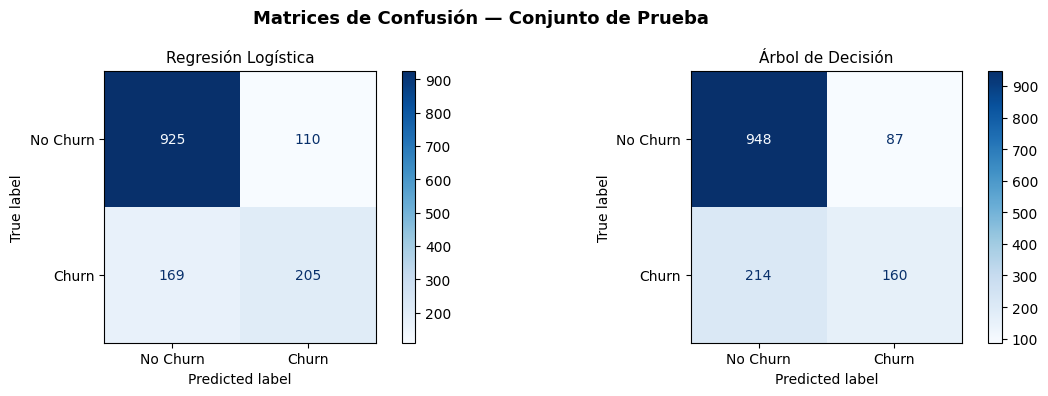

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred, _) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Churn', 'Churn'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=11)

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El caso más crítico a evaluar son los clientes que se fueron sin ser detectados (falsos negativos). Por lo tanto, la Regresión Logística resuelve mejor este problema.

* Regresión Logística: 169 de 374 casos (45.2% no detectado)
* Árbol de Decisión: 214 de 374 casos (57.2% no detectado)

**Curvas ROC**

La curva ROC muestra el balance entre la tasa de verdaderos positivos (recall)
y la tasa de falsos positivos para distintos umbrales de decisión.
Un modelo perfecto tiene AUC=1.0, un modelo aleatorio tiene AUC=0.5.

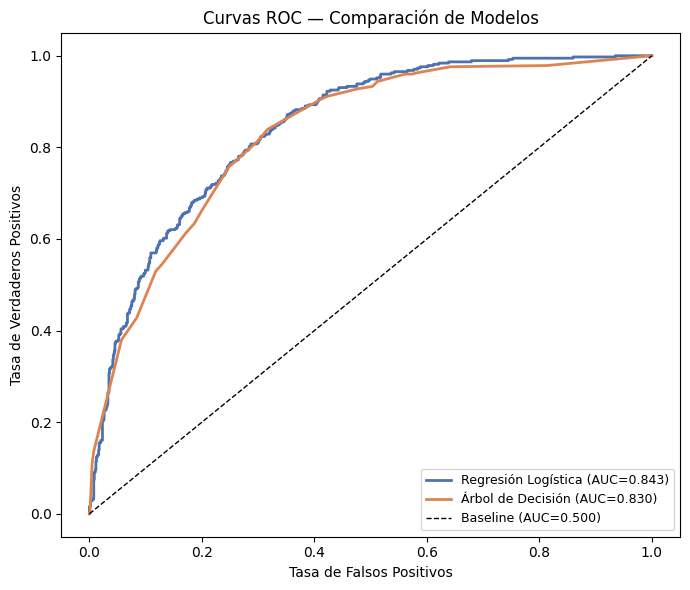

In [17]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(7, 6))
for (name, _, y_prob), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Baseline (AUC=0.500)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — Comparación de Modelos')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Ambos modelos discriminan bien entre clientes que abandonan y los que no. La diferencia es pequeña, pero favorece a la Regresión Logística. 

**Tabla comparativa de métricas**

Resumen completo del rendimiento de cada modelo sobre el conjunto de prueba.

In [22]:
rows = []
for name, y_pred, y_prob in models:
    rows.append({
        'Modelo':             name,
        'Accuracy':           round(accuracy_score(y_test, y_pred), 4),
        'Precision (Churn)':  round(precision_score(y_test, y_pred), 4),
        'Recall (Churn)':     round(recall_score(y_test, y_pred), 4),
        'F1 (Churn)':         round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':            round(roc_auc_score(y_test, y_prob), 4),
        'Escalado':           'Sí' if name == 'Regresión Logística' else 'No'
    })

summary_df = pd.DataFrame(rows).set_index('Modelo')
summary_df

,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC,Escalado
Modelo,,,,,,
Regresión Logística,0.8020,0.6508,0.5481,0.5951,0.8432,Sí
Árbol de Decisión,0.7864,0.6478,0.4278,0.5153,0.8303,No
